In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.feature_selection import f_classif, SelectKBest
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from collections import Counter
import numpy as np
from scipy.stats import randint

In [3]:
import pandas as pd
ingredient=pd.read_excel("C:/Users/HARINI/Downloads/Pizza_ingredients.xlsx")
ingredient

,pizza_name_id,pizza_name,pizza_ingredients,Items_Qty_In_Grams
0,bbq_ckn_l,The Barbecue Chicken Pizza,Barbecued Chicken,40.0
1,bbq_ckn_l,The Barbecue Chicken Pizza,Red Peppers,15.0
2,bbq_ckn_l,The Barbecue Chicken Pizza,Green Peppers,20.0
3,bbq_ckn_l,The Barbecue Chicken Pizza,Tomatoes,30.0
4,bbq_ckn_l,The Barbecue Chicken Pizza,Red Onions,60.0
...,...,...,...,...
513,veggie_veg_s,The Vegetables + Vegetables Pizza,Green Peppers,20.0
514,veggie_veg_s,The Vegetables + Vegetables Pizza,Red Onions,20.0
515,veggie_veg_s,The Vegetables + Vegetables Pizza,Zucchini,10.0
516,veggie_veg_s,The Vegetables + Vegetables Pizza,Spinach,15.0


In [4]:
ingredient.isnull().sum()

pizza_name_id         0
pizza_name            0
pizza_ingredients     0
Items_Qty_In_Grams    4
dtype: int64

In [5]:
ingredient.drop_duplicates()

,pizza_name_id,pizza_name,pizza_ingredients,Items_Qty_In_Grams
0,bbq_ckn_l,The Barbecue Chicken Pizza,Barbecued Chicken,40.0
1,bbq_ckn_l,The Barbecue Chicken Pizza,Red Peppers,15.0
2,bbq_ckn_l,The Barbecue Chicken Pizza,Green Peppers,20.0
3,bbq_ckn_l,The Barbecue Chicken Pizza,Tomatoes,30.0
4,bbq_ckn_l,The Barbecue Chicken Pizza,Red Onions,60.0
...,...,...,...,...
513,veggie_veg_s,The Vegetables + Vegetables Pizza,Green Peppers,20.0
514,veggie_veg_s,The Vegetables + Vegetables Pizza,Red Onions,20.0
515,veggie_veg_s,The Vegetables + Vegetables Pizza,Zucchini,10.0
516,veggie_veg_s,The Vegetables + Vegetables Pizza,Spinach,15.0


In [6]:
ingredient.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 518 entries, 0 to 517
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   pizza_name_id       518 non-null    object 
 1   pizza_name          518 non-null    object 
 2   pizza_ingredients   518 non-null    object 
 3   Items_Qty_In_Grams  514 non-null    float64
dtypes: float64(1), object(3)
memory usage: 16.3+ KB


In [7]:
ingredient['Items_Qty_In_Grams'] = ingredient['Items_Qty_In_Grams'].fillna(ingredient['Items_Qty_In_Grams'].median())  # Median



In [8]:
ingredient

,pizza_name_id,pizza_name,pizza_ingredients,Items_Qty_In_Grams
0,bbq_ckn_l,The Barbecue Chicken Pizza,Barbecued Chicken,40.0
1,bbq_ckn_l,The Barbecue Chicken Pizza,Red Peppers,15.0
2,bbq_ckn_l,The Barbecue Chicken Pizza,Green Peppers,20.0
3,bbq_ckn_l,The Barbecue Chicken Pizza,Tomatoes,30.0
4,bbq_ckn_l,The Barbecue Chicken Pizza,Red Onions,60.0
...,...,...,...,...
513,veggie_veg_s,The Vegetables + Vegetables Pizza,Green Peppers,20.0
514,veggie_veg_s,The Vegetables + Vegetables Pizza,Red Onions,20.0
515,veggie_veg_s,The Vegetables + Vegetables Pizza,Zucchini,10.0
516,veggie_veg_s,The Vegetables + Vegetables Pizza,Spinach,15.0


In [9]:
ingredient.isna().sum()

pizza_name_id         0
pizza_name            0
pizza_ingredients     0
Items_Qty_In_Grams    0
dtype: int64

In [10]:
ingredient.groupby('pizza_ingredients')['Items_Qty_In_Grams'].sum()

pizza_ingredients
?duja Salami                120.0
Alfredo Sauce                45.0
Anchovies                    85.0
Artichokes                  270.0
Arugula                      30.0
                            ...  
Sun-dried Tomatoes           60.0
Thai Sweet Chilli Sauce      60.0
Thyme                         5.0
Tomatoes                   1170.0
Zucchini                    120.0
Name: Items_Qty_In_Grams, Length: 64, dtype: float64

In [11]:
ingredient['Items_Qty_In_Grams']=ingredient['Items_Qty_In_Grams'].astype(int)

In [12]:
ingredient.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 518 entries, 0 to 517
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   pizza_name_id       518 non-null    object
 1   pizza_name          518 non-null    object
 2   pizza_ingredients   518 non-null    object
 3   Items_Qty_In_Grams  518 non-null    int64 
dtypes: int64(1), object(3)
memory usage: 16.3+ KB


In [13]:
from sklearn.preprocessing import LabelEncoder
categorical_cols = ingredient.select_dtypes(include=['object']).columns

# Create a new LabelEncoder instance
le_df = LabelEncoder()

# Apply LabelEncoder to each categorical column
label_encoders = {}
for column in categorical_cols:
    le = LabelEncoder()  # create a fresh encoder for each column
    ingredient[column] = le.fit_transform(ingredient[column])
    label_encoders[column] = le
ingredient.head()

,pizza_name_id,pizza_name,pizza_ingredients,Items_Qty_In_Grams
0,0,0,8,40
1,0,0,52,15
2,0,0,31,20
3,0,0,62,30
4,0,0,51,60


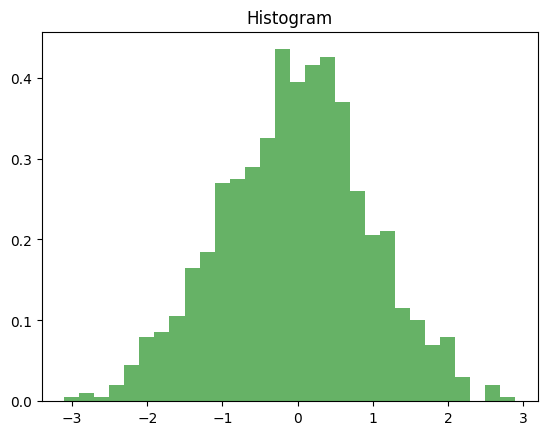

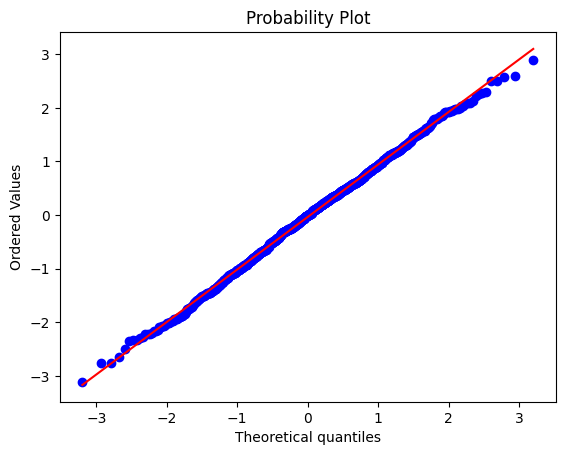

Shapiro-Wilk Test: Statistics=0.999, p=0.571
Data looks Gaussian (normal distribution)


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Example data
data = np.random.normal(loc=0, scale=1, size=1000)

# Histogram
plt.hist(data, bins=30, density=True, alpha=0.6, color='g')
plt.title("Histogram")
plt.show()

# Q-Q Plot
stats.probplot(data, dist="norm", plot=plt)
plt.show()

# Shapiro-Wilk Test
stat, p = stats.shapiro(data)
print("Shapiro-Wilk Test: Statistics=%.3f, p=%.3f" % (stat, p))
if p > 0.05:
    print("Data looks Gaussian (normal distribution)")
else:
    print("Data does not look Gaussian")

In [19]:
ingredient.to_csv('ingredient.csv', index=False)